# Single frame CLIP embedding quality check

This notebook runs a single-frame version of your residual data pipeline:
1. Load one scene and one frame.
2. Render instance segmentation from labels.instances.annotated.v2.ply.
3. Select one object id.
4. Extract masked crop.
5. Compute CLIP image embedding.
6. Optionally compare with stored embedding from clip_embedding_dataset.

In [50]:
import json
from pathlib import Path
from typing import Tuple

import cv2
import numpy as np
import torch
import clip
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

DATASET_ROOT = Path('/home/abdou/Projects/Python/RTSGS/Datasets/3rscan_full_data')
OBJECTS_JSON = Path('/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/objects.json')
CLIP_SCAN_JSON_DIR = Path('/home/abdou/Projects/Python/RTSGS/SceneGraph/clip_embedding_dataset/scans')

# Edit these three values for your check
SCAN_ID = '2e4a3964-d452-21a0-9de5-4f7895499143'
FRAME_INDEX = 0
OBJECT_ID = '2'

# View correction: apply after loading/rendering, before mask extraction.
# ROTATE_K uses np.rot90 convention: 1=90deg CCW, 2=180deg, 3=270deg CCW.
# Default changed to 3 to fix upside-down output in this scene.
ROTATE_K = 3
APPLY_FLIP_LR = False

# Extra rotation used specifically for CLIP cosine similarity.
# Set to 0/1/2/3 to choose which rotated crop is embedded.
SIM_ROTATE_K = 0

CLIP_MODEL_NAME = 'ViT-L/14'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [51]:
def parse_info_txt(path: Path) -> dict:
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '=' not in line:
                continue
            k, v = line.split('=', 1)
            out[k.strip()] = v.strip()
    return out

def parse_pose_txt(path: Path) -> np.ndarray:
    raw = path.read_text(encoding='utf-8')
    vals = [float(x) for x in raw.replace('\n', ' ').split()]
    assert len(vals) == 16, f'pose file must have 16 values, got {len(vals)}'
    return np.asarray(vals, dtype=np.float32).reshape(4, 4)

def parse_hex_color(hex_color: str) -> Tuple[int, int, int]:
    h = hex_color.strip().lstrip('#')
    assert len(h) == 6, f'invalid color: {hex_color}'
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def rgb_to_color_key(rgb: Tuple[int, int, int]) -> int:
    r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])
    return (r << 16) | (g << 8) | b

def rgb_image_to_color_key_image(rgb_img: np.ndarray) -> np.ndarray:
    r = rgb_img[:, :, 0].astype(np.int32)
    g = rgb_img[:, :, 1].astype(np.int32)
    b = rgb_img[:, :, 2].astype(np.int32)
    return (r << 16) | (g << 8) | b

def mask_to_crop(rgb: np.ndarray, mask: np.ndarray, blur_ksize: int = 31, blur_sigma: float = 0.0):
    ys, xs = np.where(mask)
    if ys.size == 0:
        return None, None, None

    y0, y1 = int(ys.min()), int(ys.max())
    x0, x1 = int(xs.min()), int(xs.max())

    roi = rgb[y0:y1+1, x0:x1+1]
    roi_mask = mask[y0:y1+1, x0:x1+1]

    k = int(max(3, blur_ksize))
    if k % 2 == 0:
        k += 1

    blurred_roi = cv2.GaussianBlur(roi, (k, k), sigmaX=blur_sigma)

    crop_blur_bg = blurred_roi.copy()
    crop_blur_bg[roi_mask] = roi[roi_mask]

    crop_black_bg = np.zeros_like(roi)
    crop_black_bg[roi_mask] = roi[roi_mask]

    return crop_blur_bg, crop_black_bg, [x0, y0, x1, y1]

In [52]:
import trimesh
import pyrender

class OpenGLSegmentedMeshRenderer:
    def __init__(self, mesh_path: Path, width: int, height: int):
        tm = trimesh.load(str(mesh_path), process=False)
        if isinstance(tm, trimesh.Scene):
            if len(tm.geometry) == 0:
                raise RuntimeError(f'Empty mesh scene: {mesh_path}')
            tm = trimesh.util.concatenate(tuple(tm.geometry.values()))
        if not hasattr(tm.visual, 'vertex_colors') or tm.visual.vertex_colors is None:
            raise RuntimeError('Mesh has no vertex colors for object-id rendering')

        self.scene = pyrender.Scene(bg_color=[0.0, 0.0, 0.0, 0.0], ambient_light=[1.0, 1.0, 1.0, 1.0])
        self.mesh = pyrender.Mesh.from_trimesh(tm, smooth=False)
        self.scene.add(self.mesh)
        self.width = int(width)
        self.height = int(height)
        self.renderer = pyrender.OffscreenRenderer(viewport_width=self.width, viewport_height=self.height)
        self.cv_to_gl = np.array(
            [[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]],
            dtype=np.float32,
        )

    def render_vertex_color_image(self, t_wc: np.ndarray, k: np.ndarray, h: int, w: int) -> np.ndarray:
        if int(w) != self.width or int(h) != self.height:
            self.renderer.delete()
            self.width = int(w)
            self.height = int(h)
            self.renderer = pyrender.OffscreenRenderer(viewport_width=self.width, viewport_height=self.height)

        fx, fy = float(k[0, 0]), float(k[1, 1])
        cx, cy = float(k[0, 2]), float(k[1, 2])
        cam = pyrender.IntrinsicsCamera(fx=fx, fy=fy, cx=cx, cy=cy, znear=0.01, zfar=1000.0)
        cam_pose_gl = (t_wc @ self.cv_to_gl).astype(np.float32)

        cam_node = self.scene.add(cam, pose=cam_pose_gl)
        color, _ = self.renderer.render(self.scene, flags=pyrender.constants.RenderFlags.FLAT)
        self.scene.remove_node(cam_node)

        if color.ndim == 3 and color.shape[2] >= 3:
            return color[:, :, :3].astype(np.uint8)
        raise RuntimeError('Invalid renderer output')

    def close(self):
        if self.renderer is not None:
            self.renderer.delete()
            self.renderer = None

In [53]:
scan_dir = DATASET_ROOT / SCAN_ID
sequence_dir = scan_dir / 'sequence'
mesh_path = scan_dir / 'labels.instances.annotated.v2.ply'
info_path = sequence_dir / '_info.txt'
color_path = sequence_dir / f'frame-{FRAME_INDEX:06d}.color.jpg'
pose_path = sequence_dir / f'frame-{FRAME_INDEX:06d}.pose.txt'

for p in [scan_dir, sequence_dir, mesh_path, info_path, color_path, pose_path, OBJECTS_JSON]:
    if not p.exists():
        raise FileNotFoundError(f'Missing path: {p}')

with open(OBJECTS_JSON, 'r', encoding='utf-8') as f:
    objects_data = json.load(f)

scan_entry = next((s for s in objects_data.get('scans', []) if str(s.get('scan')) == SCAN_ID), None)
if scan_entry is None:
    raise RuntimeError(f'Scan id not found in objects.json: {SCAN_ID}')

obj_entry = next((o for o in scan_entry.get('objects', []) if str(o.get('id')) == str(OBJECT_ID)), None)
if obj_entry is None:
    raise RuntimeError(f'Object id {OBJECT_ID} not found in scan {SCAN_ID}')

obj_color_rgb = parse_hex_color(str(obj_entry.get('ply_color', '#000000')))
obj_color_key = rgb_to_color_key(obj_color_rgb)
obj_label = str(obj_entry.get('label', 'unknown'))
obj_global_id = str(obj_entry.get('global_id', 'None'))

info = parse_info_txt(info_path)
color_w = int(info['m_colorWidth'])
color_h = int(info['m_colorHeight'])
k_color_vals = [float(x) for x in info['m_calibrationColorIntrinsic'].split()]
k_color = np.asarray(k_color_vals, dtype=np.float32).reshape(4, 4)[:3, :3]

# Respect EXIF orientation to avoid accidental flipped/rotated JPEG reads.
rgb = np.asarray(ImageOps.exif_transpose(Image.open(color_path).convert('RGB')))
t_wc = parse_pose_txt(pose_path)

renderer = OpenGLSegmentedMeshRenderer(mesh_path, width=color_w, height=color_h)
rendered_obj_rgb = renderer.render_vertex_color_image(t_wc=t_wc, k=k_color, h=color_h, w=color_w)
renderer.close()

if rendered_obj_rgb.shape[:2] != rgb.shape[:2]:
    rendered_obj_rgb = cv2.resize(rendered_obj_rgb, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

# Apply the same view correction to camera image and rendered segmentation.
if APPLY_FLIP_LR:
    rgb = np.ascontiguousarray(np.fliplr(rgb))
    rendered_obj_rgb = np.ascontiguousarray(np.fliplr(rendered_obj_rgb))
if int(ROTATE_K) % 4 != 0:
    rgb = np.ascontiguousarray(np.rot90(rgb, int(ROTATE_K) % 4))
    rendered_obj_rgb = np.ascontiguousarray(np.rot90(rendered_obj_rgb, int(ROTATE_K) % 4))

color_key_img = rgb_image_to_color_key_image(rendered_obj_rgb)
mask = color_key_img == obj_color_key
visible_pixels = int(mask.sum())
crop_blur, crop_black, bbox = mask_to_crop(rgb, mask, blur_ksize=31, blur_sigma=0.0)
crop = crop_blur

print('scan:', SCAN_ID)
print('frame:', FRAME_INDEX)
print('object_id:', OBJECT_ID)
print('global_id:', obj_global_id)
print('label:', obj_label)
print('ply_color:', obj_color_rgb)
print('visible_pixels:', visible_pixels)
print('bbox:', bbox)
print('view_transform: rotate_k=', int(ROTATE_K) % 4, ', flip_lr=', bool(APPLY_FLIP_LR), sep='')
print('crop_mode: blurred background')

scan: 2e4a3964-d452-21a0-9de5-4f7895499143
frame: 0
object_id: 2
global_id: 503
label: wall
ply_color: (31, 119, 180)
visible_pixels: 113006
bbox: [0, 0, 539, 488]
view_transform: rotate_k=3, flip_lr=False
crop_mode: blurred background


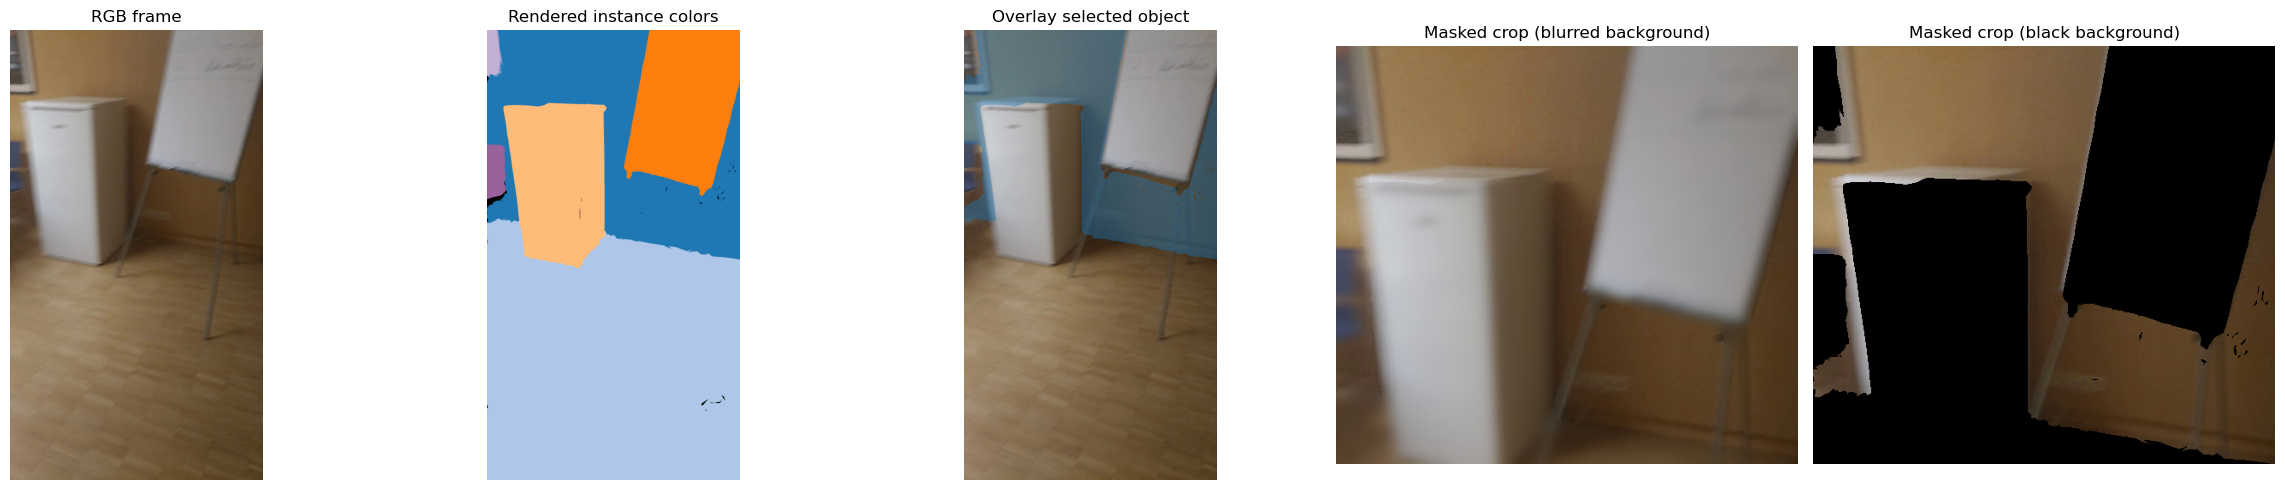

In [54]:
if crop is None:
    raise RuntimeError('Selected object is not visible in this frame. Try another frame index.')

overlay = rgb.copy()
overlay[mask] = (0.55 * overlay[mask] + 0.45 * np.array(obj_color_rgb, dtype=np.float32)).astype(np.uint8)

fig, ax = plt.subplots(1, 5, figsize=(24, 5))
ax[0].imshow(rgb)
ax[0].set_title('RGB frame')
ax[0].axis('off')

ax[1].imshow(rendered_obj_rgb)
ax[1].set_title('Rendered instance colors')
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title('Overlay selected object')
ax[2].axis('off')

ax[3].imshow(crop)
ax[3].set_title('Masked crop (blurred background)')
ax[3].axis('off')

ax[4].imshow(crop_black)
ax[4].set_title('Masked crop (black background)')
ax[4].axis('off')

plt.tight_layout()
plt.show()

100%|███████████████████████████████████████| 890M/890M [14:57<00:00, 1.04MiB/s]


Computed embedding shape: (768,)
Cosine image source: crop rotated by 0 degrees CCW


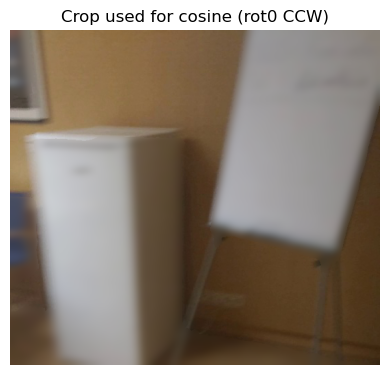

ValueError: shapes (768,) and (512,) not aligned: 768 (dim 0) != 512 (dim 0)

In [55]:
clip_model, clip_preprocess = clip.load(CLIP_MODEL_NAME, device=DEVICE)
clip_model.eval()

if crop_black is None:
    raise RuntimeError("Masked crop is None. Run the visualization/mask cell first with a visible object.")

# Use the masked image (black background) for cosine similarity.
sim_rotate_k = int(SIM_ROTATE_K) % 4
crop_for_similarity = np.ascontiguousarray(np.rot90(crop_black, sim_rotate_k))

with torch.no_grad():
    x = clip_preprocess(Image.fromarray(crop_for_similarity)).unsqueeze(0).to(DEVICE)
    emb_img = clip_model.encode_image(x)
    emb_img = emb_img / emb_img.norm(dim=-1, keepdim=True).clamp_min(1e-8)

emb_img_np = emb_img[0].detach().cpu().numpy().astype(np.float32)

print('Computed embedding shape:', emb_img_np.shape)
print('Cosine image source: masked crop (black bg), rotated by', sim_rotate_k * 90, 'degrees CCW')

plt.figure(figsize=(4, 4))
plt.imshow(crop_for_similarity)
plt.title(f'Masked crop used for cosine (rot{sim_rotate_k * 90} CCW)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Optional comparison with stored residual-pipeline embedding for same frame/object
stored_path = CLIP_SCAN_JSON_DIR / f'{SCAN_ID}.json'
if stored_path.exists():
    with open(stored_path, 'r', encoding='utf-8') as f:
        d = json.load(f)
    obj_block = d.get('objects', {}).get(str(OBJECT_ID), None)
    matched = None
    if obj_block is not None:
        for e in obj_block.get('embeddings', []):
            if int(e.get('frame_index', -1)) == int(FRAME_INDEX):
                matched = np.asarray(e.get('embedding'), dtype=np.float32)
                break
    if matched is not None:
        matched = matched / (np.linalg.norm(matched) + 1e-8)
        cos = float(np.dot(emb_img_np, matched))
        print('Cosine with stored embedding (same object/frame):', f'{cos:.6f}')
    else:
        print('No stored embedding found for this object/frame in clip_embedding_dataset.')
else:
    print('clip_embedding_dataset scan json not found, skipping stored-comparison.')

Cosine similarity (image vs text prompts):
 1. +0.190592  |  a photo of furniture
 2. +0.189597  |  an indoor scene object
 3. +0.178472  |  wall
 4. +0.173826  |  a photo of a wall
 5. +0.172515  |  a photo of a bottle
 6. +0.170372  |  a photo of a vase
 7. +0.158654  |  a photo of a cup


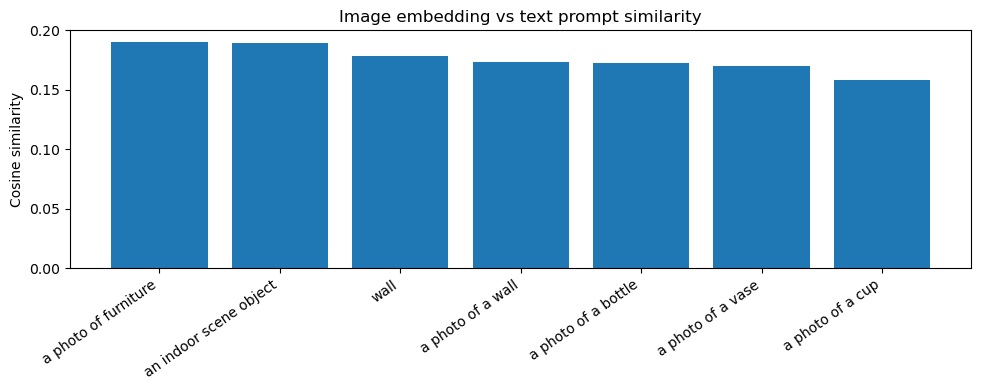

In [56]:
# Compare image embedding against multiple text prompts with cosine similarity
# This assumes the previous CLIP cell has already computed `emb_img`.

text_prompts = [
    f"a photo of a {obj_label}",
    f"{obj_label}",
    "a photo of a bottle",
    "a photo of a vase",
    "a photo of a cup",
    "a photo of furniture",
    "an indoor scene object",
]

if 'emb_img' not in globals():
    raise RuntimeError("Run the CLIP image embedding cell first to compute `emb_img`.")

with torch.no_grad():
    text_tokens = clip.tokenize(text_prompts).to(DEVICE)
    text_emb = clip_model.encode_text(text_tokens)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True).clamp_min(1e-8)

# emb_img shape: [1, 512], text_emb shape: [N, 512]
sims = torch.matmul(emb_img.float(), text_emb.float().T).squeeze(0).detach().cpu().numpy()

ranking = sorted(zip(text_prompts, sims.tolist()), key=lambda x: x[1], reverse=True)

print("Cosine similarity (image vs text prompts):")
for i, (prompt, score) in enumerate(ranking, start=1):
    print(f"{i:2d}. {score:+.6f}  |  {prompt}")

# Optional quick bar plot
labels = [p for p, _ in ranking]
values = [v for _, v in ranking]

plt.figure(figsize=(10, 4))
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=35, ha='right')
plt.ylabel('Cosine similarity')
plt.title('Image embedding vs text prompt similarity')
plt.tight_layout()
plt.show()

In [ ]:
# Rotation sanity plot: compare all 4 rotations of the current corrected RGB/crop.
if crop is None:
    raise RuntimeError('Crop is None. Run previous cells first.')

rot_titles = ['0 deg', '90 deg CCW', '180 deg', '270 deg CCW']
fig, ax = plt.subplots(2, 4, figsize=(18, 8))

for k in range(4):
    rgb_k = np.ascontiguousarray(np.rot90(rgb, k))
    crop_k = np.ascontiguousarray(np.rot90(crop, k))

    ax[0, k].imshow(rgb_k)
    ax[0, k].set_title(f'RGB {rot_titles[k]}')
    ax[0, k].axis('off')

    ax[1, k].imshow(crop_k)
    ax[1, k].set_title(f'Crop {rot_titles[k]}')
    ax[1, k].axis('off')

plt.tight_layout()
plt.show()